In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
transactions_file_path = "transactions_data_cleaned.csv"
products_file_path = "products_data_cleaned.csv"
customers_file_path = "customers_data_cleaned.csv"

In [3]:
transactions_data = pd.read_csv(transactions_file_path)
products_data = pd.read_csv(products_file_path)
customers_data = pd.read_csv(customers_file_path)

In [4]:
customer_spending = transactions_data.groupby("Company_ID").agg(
    Total_Spent_Per_Customer=("Total_Cost", "sum"),
    Transaction_Frequency=("Transaction_ID", "count"),
    Average_Quantity_Per_Transaction=("Quantity", "mean"),
    Repeat_Purchases=("Product_ID", lambda x: x.duplicated().sum())  # Likelihood to Recommend
).reset_index()

In [5]:
customer_data = customers_data.merge(customer_spending, on="Company_ID", how="left")
customer_data.fillna(0, inplace=True)  # Handle missing values

In [6]:
customer_data["Likelihood_to_Recommend"] = (customer_data["Repeat_Purchases"] / customer_data["Transaction_Frequency"]) * 100
customer_data["Likelihood_to_Recommend"] = customer_data["Likelihood_to_Recommend"].fillna(0).round(2)

In [7]:
customer_data["Satisfaction_Rating"] = customer_data["Transaction_Frequency"].apply(lambda x: "High" if x > 10 else "Medium" if x > 5 else "Low")

In [8]:
features = ["Company_Profit", "Total_Spent_Per_Customer", "Transaction_Frequency", "Average_Quantity_Per_Transaction"]
X = customer_data[features]

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

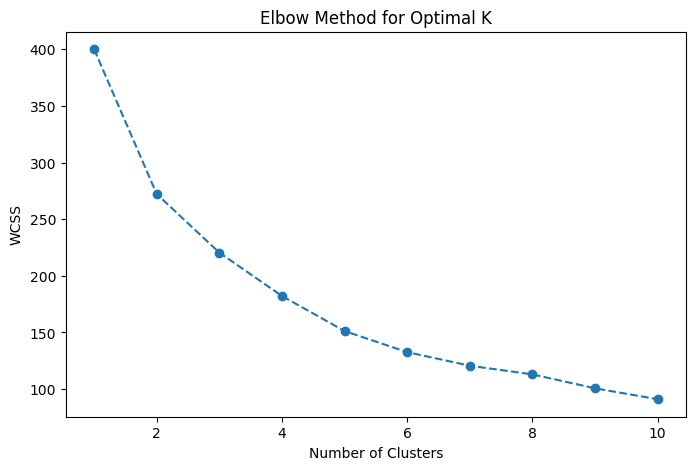

In [10]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_data["Customer_Segment"] = kmeans.fit_predict(X_scaled)

In [12]:
transaction_product_mapping = transactions_data.groupby(["Company_ID", "Product_ID"]).size().reset_index(name="Purchase_Count")
most_likely_products = transaction_product_mapping.loc[transaction_product_mapping.groupby("Company_ID")["Purchase_Count"].idxmax()][["Company_ID", "Product_ID"]]

In [13]:
customer_data = customer_data.merge(most_likely_products, on="Company_ID", how="left")

In [14]:
customer_data[["Company_ID", "Customer_Segment", "Product_ID", "Likelihood_to_Recommend", "Satisfaction_Rating"]].rename(columns={"Product_ID": "Most_Likely_Product"}).to_csv("customer_product_predictions.csv", index=False)